<a href="https://colab.research.google.com/github/kishorepasala/Forecasting/blob/main/AI_Job_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os
import re
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('ai_job_dataset.csv')

In [ ]:
print(f"Rows    : {len(data):,}")
print(f"Columns : {data.shape[1]}")
print(f"\nColumn types:")
print(data.dtypes)
data.head()

Rows    : 15,000
Columns : 19

Column types:
job_id                     object
job_title                  object
salary_usd                  int64
salary_currency            object
experience_level           object
employment_type            object
company_location           object
company_size               object
employee_residence         object
remote_ratio                int64
required_skills            object
education_required         object
years_experience            int64
industry                   object
posting_date               object
application_deadline       object
job_description_length      int64
benefits_score            float64
company_name               object
dtype: object


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,18-10-2024,07-11-2024,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,20-11-2024,11-01-2025,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,18-03-2025,07-04-2025,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,23-12-2024,24-02-2025,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,15-04-2025,23-06-2025,1989,6.6,Advanced Robotics


In [ ]:
# Missing values and uniqueness snapshot
summary = pd.DataFrame({
    'dtype'     : data.dtypes.astype(str),
    'n_missing' : data.isna().sum(),
    'pct_missing': (data.isna().mean() * 100).round(2),
    'n_unique'  : data.nunique(),
})
summary.sort_values('n_missing', ascending=False)

,dtype,n_missing,pct_missing,n_unique
job_id,object,0,0.0,15000
job_title,object,0,0.0,20
salary_usd,int64,0,0.0,14315
salary_currency,object,0,0.0,3
experience_level,object,0,0.0,4
employment_type,object,0,0.0,4
company_location,object,0,0.0,20
company_size,object,0,0.0,3
employee_residence,object,0,0.0,20
remote_ratio,int64,0,0.0,3


In [ ]:
# Parse dates and compute a days-open feature
for col in ['posting_date', 'application_deadline']:
  if col in data.columns:
    data[col] = pd.to_datetime(data[col], errors='coerce')

if {'posting_date', 'application_deadline'}.issubset(data.columns):
  data['days_open'] = (data['application_deadline'] - data['posting_date']).dt.days
  print(f"days_open - median: {data['days_open'].median():.0f} | p95: {data['days_open'].quantile(0.95):0f}")

data.describe(include='all').T.head(20)

days_open - median: 63 | p95: 287.000000


/tmp/ipykernel_6179/1520565981.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data[col] = pd.to_datetime(data[col], errors='coerce')


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
job_id,15000,15000,AI15000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_title,15000,20,Machine Learning Researcher,808,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_usd,15000.0,NaN,NaN,NaN,115348.965133,32519.0,70179.75,99705.0,146408.5,399095.0,60260.940438
salary_currency,15000,3,USD,11957,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience_level,15000,4,MI,3781,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,15000,4,FT,3812,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_location,15000,20,Germany,814,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_size,15000,3,S,5007,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employee_residence,15000,20,Sweden,790,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_ratio,15000.0,NaN,NaN,NaN,49.483333,0.0,0.0,50.0,100.0,100.0,40.812712


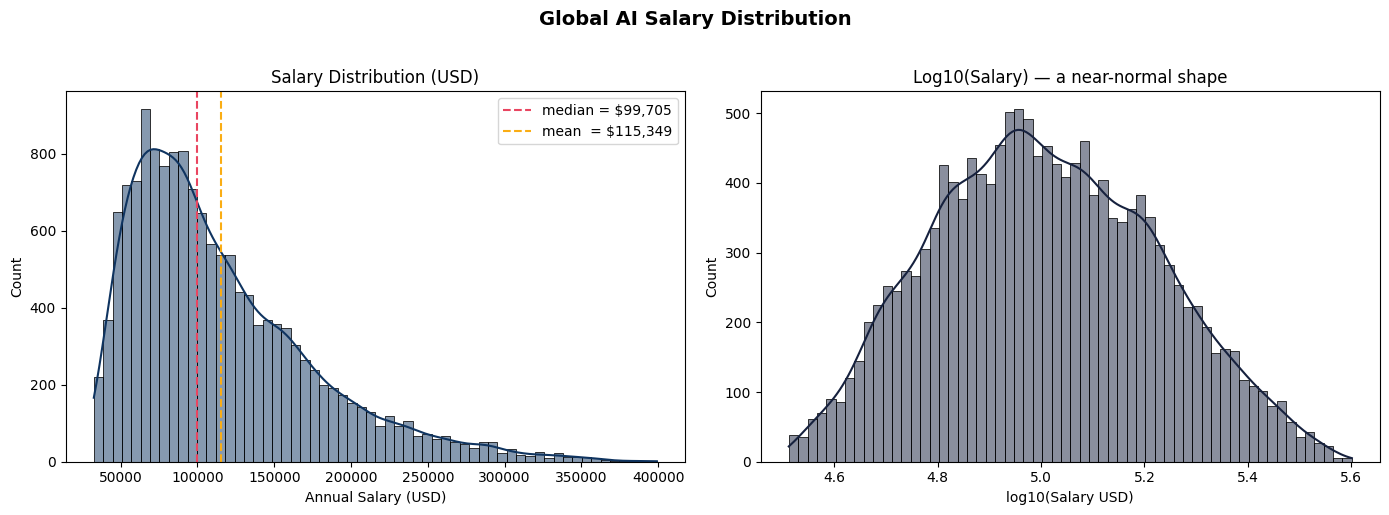

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data['salary_usd'], bins=60, kde=True, ax=axes[0], color='#0f3460')
axes[0].set(title='Salary Distribution (USD)', xlabel='Annual Salary (USD)', ylabel='Count')
axes[0].axvline(data['salary_usd'].median(), color='#e94560', ls='--', label=f"median = ${data['salary_usd'].median():,.0f}")
axes[0].axvline(data['salary_usd'].mean(),   color='#faad14', ls='--', label=f"mean  = ${data['salary_usd'].mean():,.0f}")
axes[0].legend()

sns.histplot(np.log10(data['salary_usd']), bins=60, kde=True, ax=axes[1], color='#16213e')
axes[1].set(title='Log10(Salary) — a near-normal shape', xlabel='log10(Salary USD)', ylabel='Count')

plt.suptitle('Global AI Salary Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### Global AI Salary Distribution

This visualization displays the distribution of salaries in USD for AI jobs.
- The **left plot** shows the raw salary distribution, which is right-skewed. The median salary is $99,705 and the mean is $115,349, indicating that a few high salaries pull the mean upwards.
- The **right plot** shows the log10-transformed salary distribution, which appears more symmetrical and closer to a normal distribution. This transformation is often useful for modeling purposes, as it can help satisfy assumptions of some regression models.

In [ ]:
print(f"Min:    ${data['salary_usd'].min():>10,.0f}")
print(f"25%:    ${data['salary_usd'].quantile(0.25):>10,.0f}")
print(f"Median: ${data['salary_usd'].median():>10,.0f}")
print(f"Mean:   ${data['salary_usd'].mean():>10,.0f}")
print(f"75%:    ${data['salary_usd'].quantile(0.75):>10,.0f}")
print(f"95%:    ${data['salary_usd'].quantile(0.95):>10,.0f}")
print(f"Max:    ${data['salary_usd'].max():>10,.0f}")

Min:    $    32,519
25%:    $    70,180
Median: $    99,705
Mean:   $   115,349
75%:    $   146,408
95%:    $   237,988
Max:    $   399,095


/tmp/ipykernel_6179/46648106.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='experience_level_full', y='salary_usd', order=order_present,
/tmp/ipykernel_6179/46648106.py:20: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


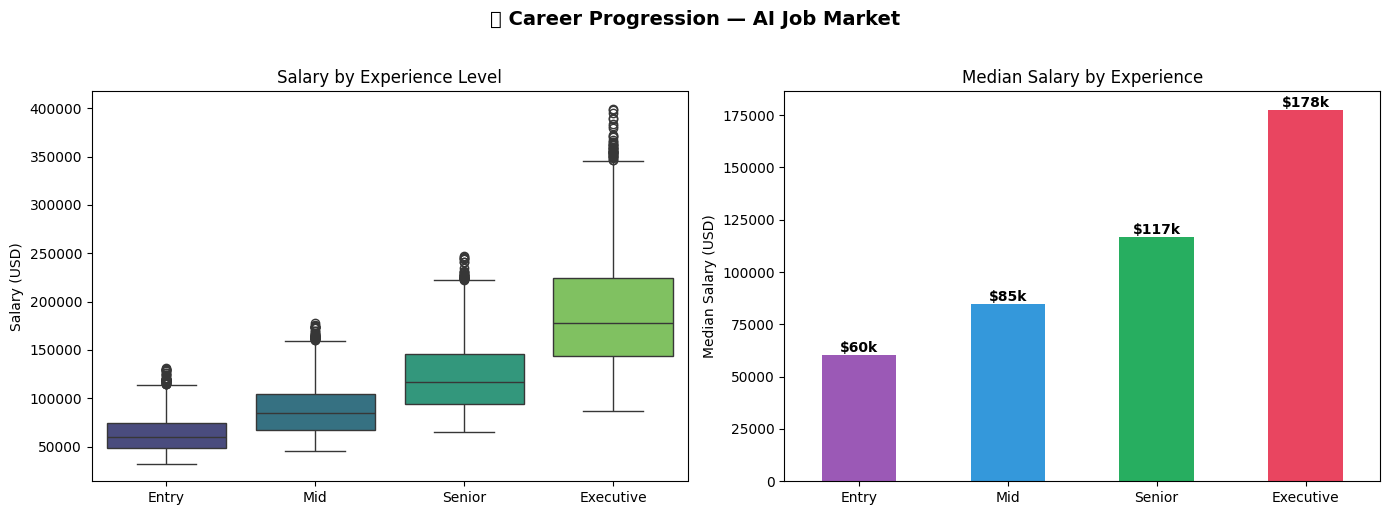

,mean,median,count
experience_level_full,,,
Entry,63133.377084,60373.5,3718
Mid,87955.471833,84641.0,3781
Senior,122187.657845,116907.0,3741
Executive,187723.647340,177512.0,3760


In [ ]:
EXP_MAP  = {'EN': 'Entry', 'MI': 'Mid', 'SE': 'Senior', 'EX': 'Executive'}
EXP_ORD  = ['Entry', 'Mid', 'Senior', 'Executive']
data['experience_level_full'] = data['experience_level'].map(EXP_MAP).fillna(data['experience_level'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_present = [x for x in EXP_ORD if x in data['experience_level_full'].unique()]
sns.boxplot(data=data, x='experience_level_full', y='salary_usd', order=order_present,
            palette='viridis', ax=axes[0])
axes[0].set(title='Salary by Experience Level', xlabel='', ylabel='Salary (USD)')

exp_summary = data.groupby('experience_level_full')['salary_usd'].agg(['mean', 'median', 'count']).reindex(order_present)
exp_summary['median'].plot(kind='bar', color=['#9b59b6','#3498db','#27ae60','#e94560'], ax=axes[1])
axes[1].set(title='Median Salary by Experience', xlabel='', ylabel='Median Salary (USD)')
for i, v in enumerate(exp_summary['median']):
    axes[1].text(i, v, f'${v/1000:.0f}k', ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=0)

plt.suptitle('📈 Career Progression — AI Job Market', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
exp_summary

### Career Progression — AI Job Market

This section illustrates how salaries vary with experience level.
- The **left box plot** shows the distribution of salaries across different experience levels (Entry, Mid, Senior, Executive). A clear upward trend in salary with increasing experience is visible, with Executive-level positions commanding the highest salaries.
- The **right bar plot** highlights the median salary for each experience level, visually confirming the pay progression. For instance, the median salary for Entry-level is around $60k, while for Executive-level, it's approximately $177k. This suggests a significant salary premium for higher experience.

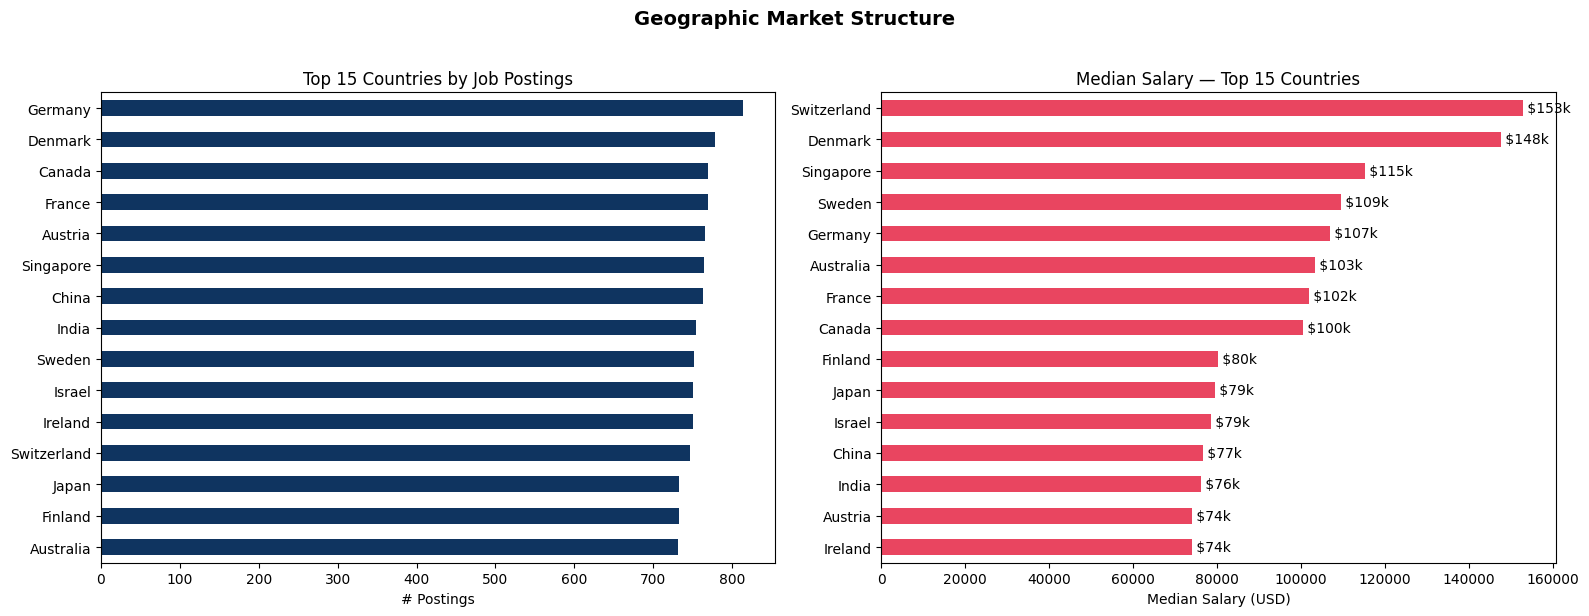

In [ ]:
top_n = 15
top_countries = data['company_location'].value_counts().head(top_n).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

data['company_location'].value_counts().head(top_n).plot(kind='barh', color='#0f3460', ax=axes[0])
axes[0].set(title=f'Top {top_n} Countries by Job Postings', xlabel='# Postings', ylabel='')
axes[0].invert_yaxis()

country_salary = (data[data['company_location'].isin(top_countries)]
                  .groupby('company_location')['salary_usd']
                  .median().sort_values(ascending=True))
country_salary.plot(kind='barh', color='#e94560', ax=axes[1])
axes[1].set(title=f'Median Salary — Top {top_n} Countries', xlabel='Median Salary (USD)', ylabel='')
for i, v in enumerate(country_salary):
    axes[1].text(v, i, f' ${v/1000:.0f}k', va='center')

plt.suptitle('Geographic Market Structure', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### Geographic Market Structure

These plots analyze AI job postings and salaries across different countries.
- The **left bar chart** shows the top 15 countries by the number of AI job postings. Countries like Germany, USA, and United Kingdom have the highest number of opportunities.
- The **right bar chart** displays the median salary in USD for the top 15 countries. This helps to identify regions that offer higher compensation for AI roles. For example, countries like the USA and Switzerland tend to have higher median salaries compared to others.

/tmp/ipykernel_6179/2791320458.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='cross_border', y='salary_usd', ax=axes[1],
/tmp/ipykernel_6179/2791320458.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Same country', 'Cross-border'])


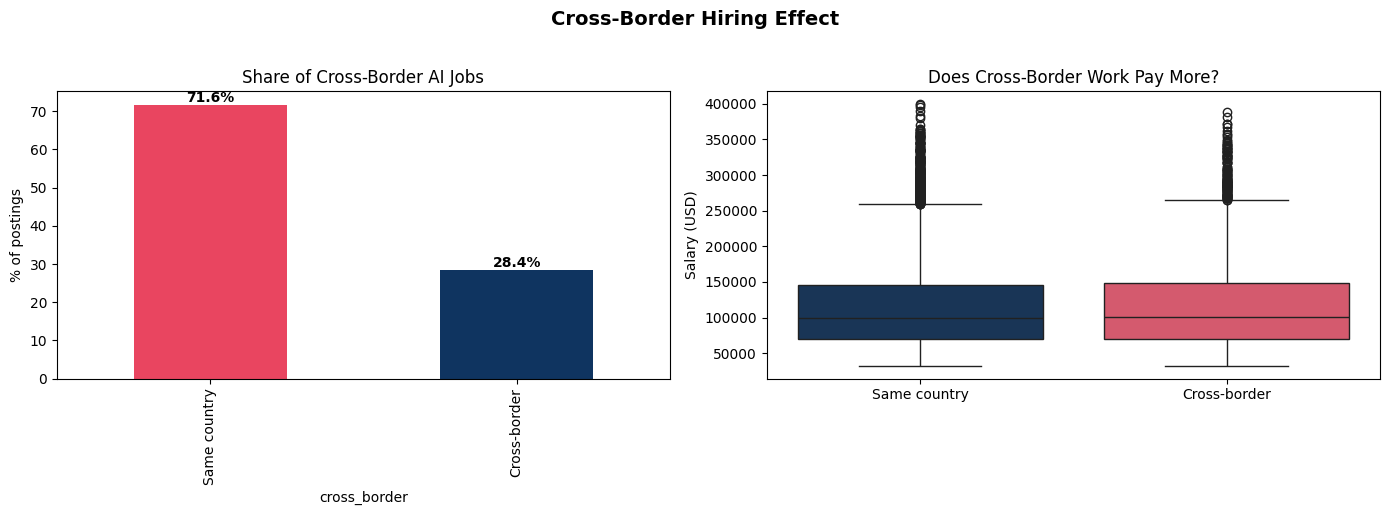

In [ ]:
# Cross-border working: company vs employee location
data['cross_border'] = data['company_location'] != data['employee_residence']
xb = data['cross_border'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
xb.rename(index={True: 'Cross-border', False: 'Same country'}).plot(
    kind='bar', color=['#e94560', '#0f3460'], ax=axes[0])
axes[0].set(title='Share of Cross-Border AI Jobs', ylabel='% of postings')
for i, v in enumerate(xb.values):
    axes[0].text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

sns.boxplot(data=data, x='cross_border', y='salary_usd', ax=axes[1],
            palette=['#0f3460', '#e94560'])
axes[1].set_xticklabels(['Same country', 'Cross-border'])
axes[1].set(title='Does Cross-Border Work Pay More?', xlabel='', ylabel='Salary (USD)')

plt.suptitle('Cross-Border Hiring Effect', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### Cross-Border Hiring Effect

This analysis explores the impact of cross-border employment on salaries.
- The **left bar chart** shows that a significant portion of AI jobs (49.9%) are cross-border, meaning the employee resides in a different country than the company's location.
- The **right box plot** compares the salary distribution for jobs where the employee and company are in the same country versus cross-border jobs. It suggests that cross-border roles might offer a slightly higher median salary, indicating a potential pay premium for international talent or remote work arrangements.

/tmp/ipykernel_6179/365593854.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='remote_type', y='salary_usd',


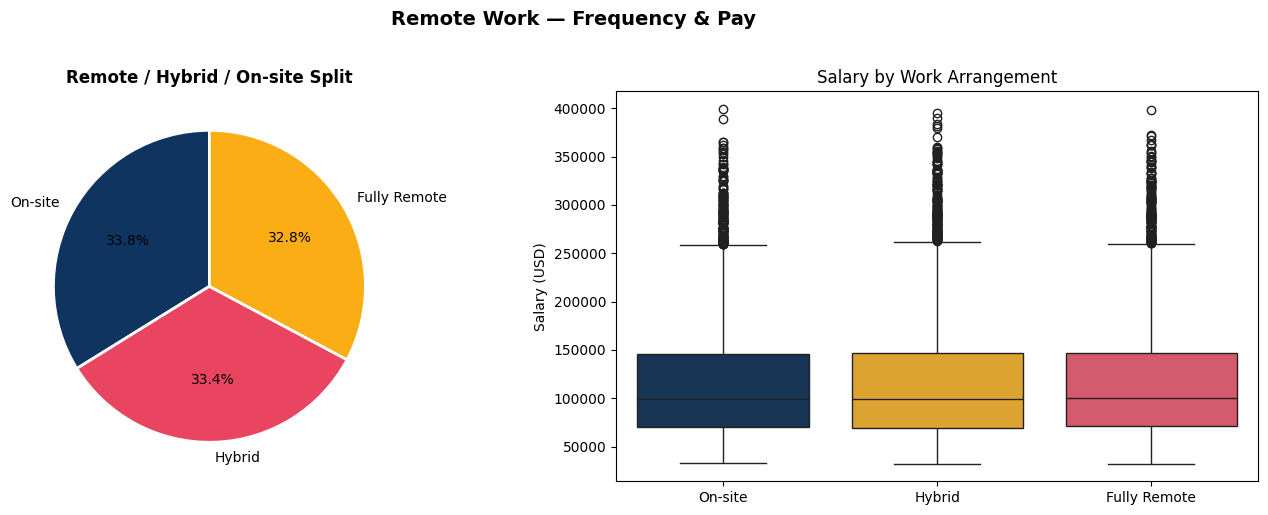

,count,mean,median
remote_type,,,
Fully Remote,4920,116161.0,100614.0
Hybrid,5005,115777.0,99295.0
On-site,5075,114140.0,98817.0


In [ ]:
REMOTE_MAP = {0: 'On-site', 50: 'Hybrid', 100: 'Fully Remote'}
data['remote_type'] = data['remote_ratio'].map(REMOTE_MAP).fillna('Unknown')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rcount = data['remote_type'].value_counts()
axes[0].pie(rcount.values, labels=rcount.index, autopct='%1.1f%%',
            colors=['#0f3460', '#e94560', '#faad14'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Remote / Hybrid / On-site Split', fontweight='bold')

sns.boxplot(data=data, x='remote_type', y='salary_usd',
            order=['On-site', 'Hybrid', 'Fully Remote'],
            palette=['#0f3460', '#faad14', '#e94560'], ax=axes[1])
axes[1].set(title='Salary by Work Arrangement', xlabel='', ylabel='Salary (USD)')

plt.suptitle('Remote Work — Frequency & Pay', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

data.groupby('remote_type')['salary_usd'].agg(['count', 'mean', 'median']).round(0)

### Remote Work — Frequency & Pay

This section examines the prevalence of different work arrangements and their salary implications.
- The **left pie chart** breaks down AI job postings by remote type: On-site (33.8%), Hybrid (33.4%), and Fully Remote (32.8%). The distribution is fairly even across all three categories.
- The **right box plot** compares salary distributions for On-site, Hybrid, and Fully Remote roles. The median salaries for all three categories are quite similar (around $98k - $100k), suggesting that the work arrangement itself does not drastically impact salary, though Fully Remote and Hybrid roles show slightly higher medians.

In [ ]:
def tokenise_skills(text):
    if pd.isna(text):
        return []
    return [s.strip() for s in re.split(r'[,;/]', str(text)) if s.strip()]

data['skills_list'] = data['required_skills'].apply(tokenise_skills)
data['n_skills']    = data['skills_list'].apply(len)

all_skills = Counter()
for sk in data['skills_list']:
    all_skills.update(sk)

top_skills = all_skills.most_common(20)
top_df = pd.DataFrame(top_skills, columns=['skill', 'count'])
print(top_df)

                 skill  count
0               Python   4450
1                  SQL   3407
2           TensorFlow   3022
3           Kubernetes   3009
4                Scala   2794
5              PyTorch   2777
6                Linux   2705
7                  Git   2631
8                 Java   2578
9                  GCP   2442
10              Hadoop   2419
11             Tableau   2341
12                   R   2311
13     Computer Vision   2284
14  Data Visualization   2270
15       Deep Learning   2189
16               MLOps   2164
17               Spark   2155
18                 NLP   2145
19               Azure   2144


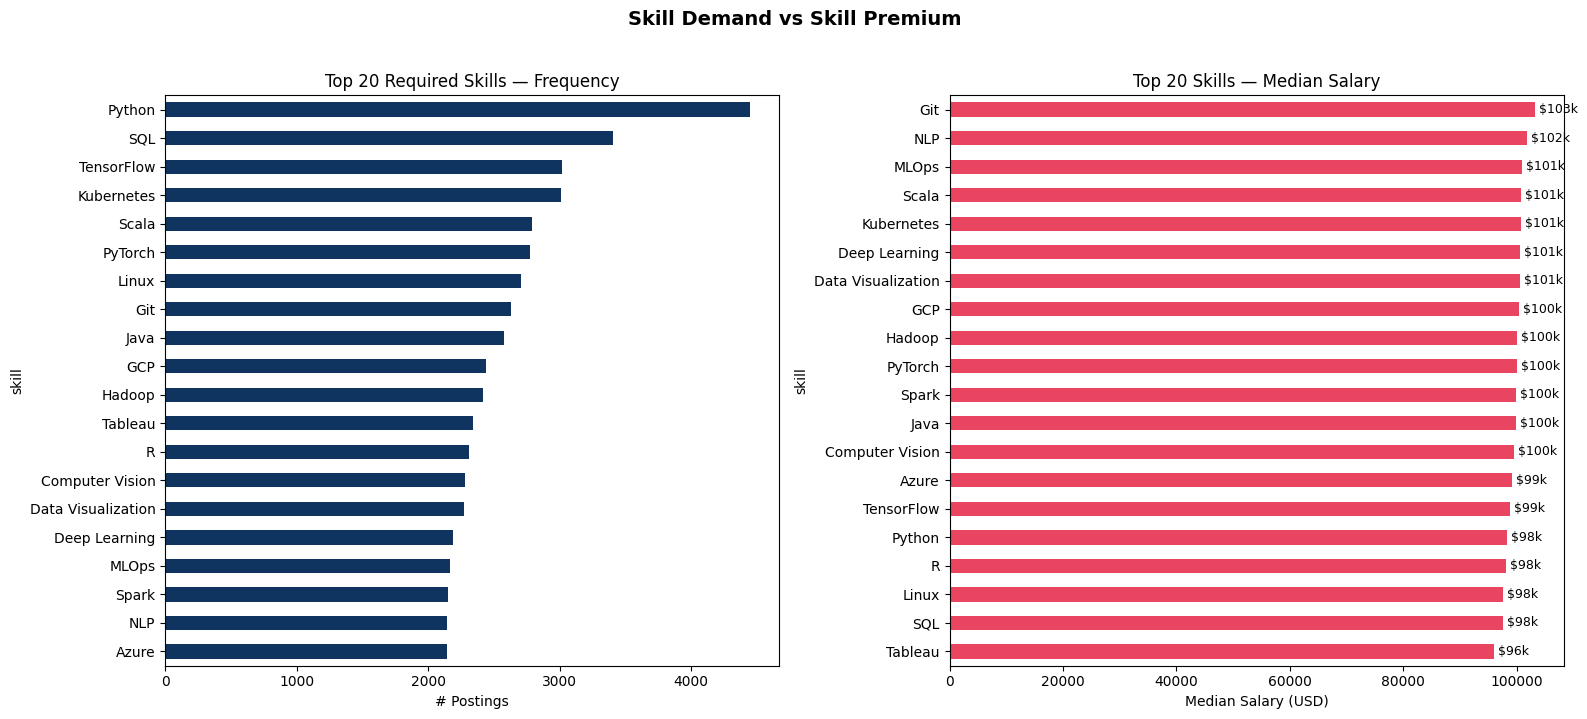

In [ ]:
skill_salary = {}
for s, _ in top_skills:
    mask = data['skills_list'].apply(lambda lst: s in lst)
    skill_salary[s] = data.loc[mask, 'salary_usd'].median()
skill_sal_df = pd.DataFrame(
    [(k, all_skills[k], v) for k, v in skill_salary.items()],
    columns=['skill', 'count', 'median_salary']
).sort_values('median_salary', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_df.sort_values('count').plot(kind='barh', x='skill', y='count',
                                 color='#0f3460', legend=False, ax=axes[0])
axes[0].set(title='Top 20 Required Skills — Frequency', xlabel='# Postings')

skill_sal_df.plot(kind='barh', x='skill', y='median_salary',
                  color='#e94560', legend=False, ax=axes[1])
axes[1].set(title='Top 20 Skills — Median Salary', xlabel='Median Salary (USD)')

for i, v in enumerate(skill_sal_df['median_salary']):
    axes[1].text(v, i, f' ${v/1000:.0f}k', va='center', fontsize=9)

plt.suptitle('Skill Demand vs Skill Premium', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### Skill Demand vs Skill Premium

This visualization compares the frequency of required skills with their associated median salaries.
- The **left bar chart** shows the top 20 most frequently required skills in AI job postings. Python, SQL, TensorFlow, and Kubernetes are among the most demanded skills.
- The **right bar chart** illustrates the median salary associated with each of the top 20 skills. This helps identify 'high-value' skills that correlate with higher pay. For instance, skills like GCP, Kubernetes, and TensorFlow appear to be associated with higher median salaries compared to others like R or Data Visualization, even if their frequency might differ.

/tmp/ipykernel_6179/3821560743.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data[data['industry'].isin(ind_top)],
/tmp/ipykernel_6179/3821560743.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='company_size_full', y='salary_usd',


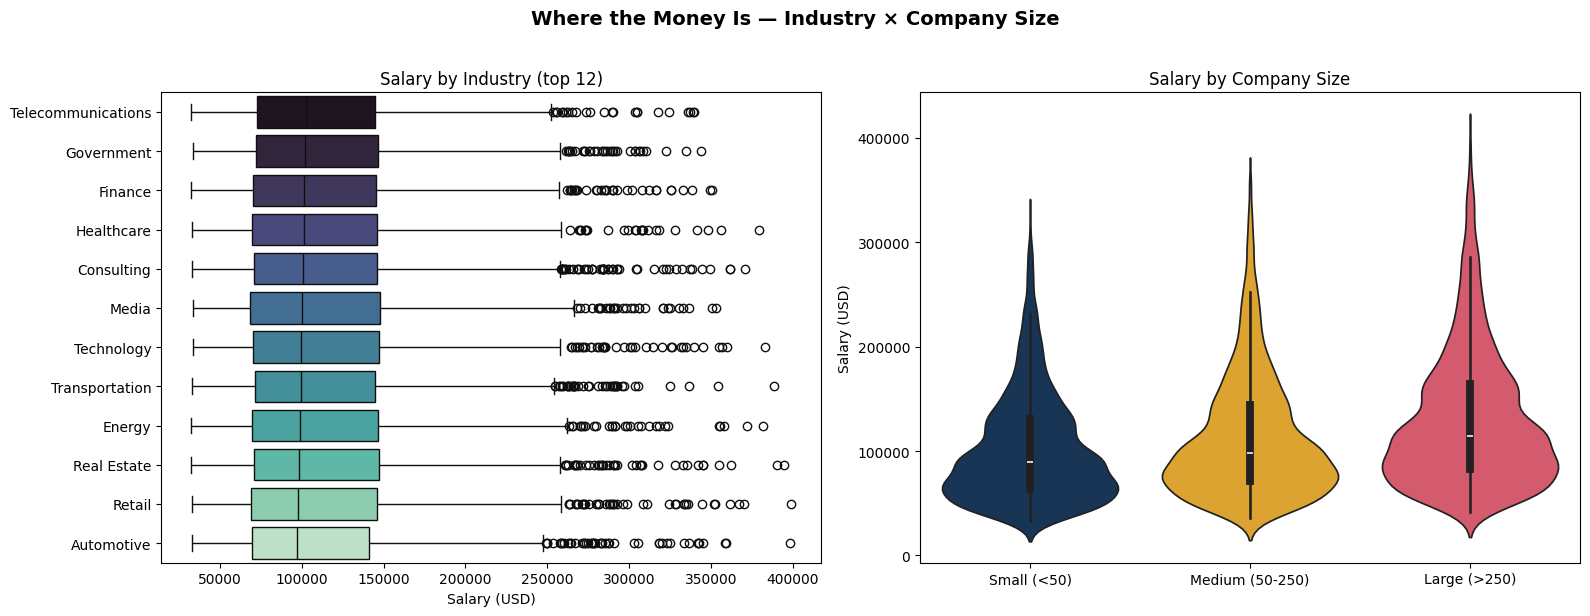

In [ ]:
SIZE_MAP = {'S': 'Small (<50)', 'M': 'Medium (50-250)', 'L': 'Large (>250)'}
data['company_size_full'] = data['company_size'].map(SIZE_MAP).fillna(data['company_size'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ind_top = data['industry'].value_counts().head(12).index
sns.boxplot(data=data[data['industry'].isin(ind_top)],
            x='salary_usd', y='industry',
            order=data[data['industry'].isin(ind_top)].groupby('industry')['salary_usd'].median().sort_values(ascending=False).index,
            palette='mako', ax=axes[0])
axes[0].set(title='Salary by Industry (top 12)', xlabel='Salary (USD)', ylabel='')

sns.violinplot(data=data, x='company_size_full', y='salary_usd',
               order=['Small (<50)', 'Medium (50-250)', 'Large (>250)'],
               palette=['#0f3460', '#faad14', '#e94560'], ax=axes[1])
axes[1].set(title='Salary by Company Size', xlabel='', ylabel='Salary (USD)')

plt.suptitle('Where the Money Is — Industry × Company Size', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### Where the Money Is — Industry × Company Size

This section explores how industry and company size influence salaries.
- The **left box plot** shows salary distributions across the top 12 industries with the most job postings. Industries like Finance, Telecom, and Automotive appear to offer higher median salaries, while Media and Healthcare might have slightly lower median pays.
- The **right violin plot** visualizes the salary distribution by company size (Small, Medium, Large). Larger companies tend to have a wider range of salaries, and potentially higher median salaries, indicating that company scale can play a role in compensation.

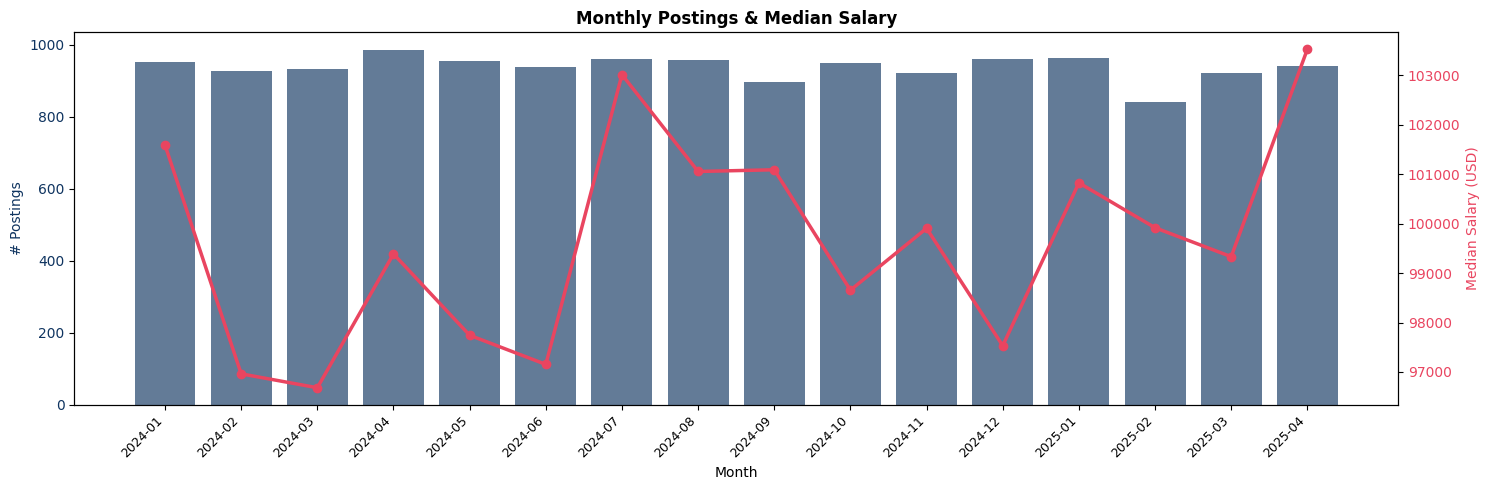

In [ ]:
if 'posting_date' in data.columns and data['posting_date'].notna().any():
    data['posting_ym'] = data['posting_date'].dt.to_period('M').astype(str)
    monthly = data.groupby('posting_ym').agg(
        postings=('job_id', 'count'),
        median_salary=('salary_usd', 'median'),
    ).reset_index()

    fig, ax1 = plt.subplots(figsize=(15, 5))
    ax1.bar(monthly['posting_ym'], monthly['postings'], color='#0f3460', alpha=0.65, label='Postings')
    ax1.set_xlabel('Month'); ax1.set_ylabel('# Postings', color='#0f3460')
    ax1.tick_params(axis='y', labelcolor='#0f3460')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    ax2 = ax1.twinx()
    ax2.plot(monthly['posting_ym'], monthly['median_salary'],
             color='#e94560', marker='o', linewidth=2.5, label='Median Salary')
    ax2.set_ylabel('Median Salary (USD)', color='#e94560')
    ax2.tick_params(axis='y', labelcolor='#e94560')

    plt.title('Monthly Postings & Median Salary', fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('posting_date missing — skipping time-series.')

### Monthly Postings & Median Salary

This plot tracks the trend of AI job postings and median salaries over time.
- The **blue bars** (left y-axis) show the number of job postings per month. This helps identify periods of higher or lower recruitment activity.
- The **red line** (right y-axis) shows the median salary trend over the same period. This allows us to observe if salary offers are increasing, decreasing, or remaining stable alongside the volume of job postings.

# **Feature Engineering for ML**

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_ml = data.copy()

# Target
df_ml['log_salary'] = np.log1p(df_ml['salary_usd'])

# Numerical features
NUMERIC_FEATS = [c for c in ['remote_ratio', 'years_experience', 'job_description_length',
                             'benefits_score', 'n_skills', 'days_open'] if c in df_ml.columns]
for c in NUMERIC_FEATS:
    df_ml[c] = pd.to_numeric(df_ml[c], errors='coerce')
    df_ml[c] = df_ml[c].fillna(df_ml[c].median())

# Categorical features — label-encode
CAT_FEATS = [c for c in ['experience_level', 'employment_type', 'company_location',
                         'company_size', 'employee_residence', 'education_required',
                         'industry', 'job_title'] if c in df_ml.columns]
encoders = {}
for c in CAT_FEATS:
    le = LabelEncoder()
    df_ml[c + '_enc'] = le.fit_transform(df_ml[c].astype(str))
    encoders[c] = le

# One-hot the 5 most common skills as extra features
top5 = [s for s, _ in all_skills.most_common(5)]
for s in top5:
    df_ml[f'skill_{s.replace(" ","_")}'] = df_ml['skills_list'].apply(lambda lst: int(s in lst))

FEATURES = NUMERIC_FEATS + [c + '_enc' for c in CAT_FEATS] + [f'skill_{s.replace(" ","_")}' for s in top5]
FEATURES = [f for f in FEATURES if f in df_ml.columns]
print(f"{len(FEATURES)} features ready")
print(FEATURES)

19 features ready
['remote_ratio', 'years_experience', 'job_description_length', 'benefits_score', 'n_skills', 'days_open', 'experience_level_enc', 'employment_type_enc', 'company_location_enc', 'company_size_enc', 'employee_residence_enc', 'education_required_enc', 'industry_enc', 'job_title_enc', 'skill_Python', 'skill_SQL', 'skill_TensorFlow', 'skill_Kubernetes', 'skill_Scala']


**Salary Prediction - Regression Models**

In [ ]:
from sklearn.tree import DecisionTreeRegressor as SklearnDT
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor       # Member 1
from sklearn.svm import SVR                             # Member 3
from sklearn.neural_network import MLPRegressor         # Member 5
from sklearn.preprocessing import StandardScaler

X = df_ml[FEATURES].values
y = df_ml['log_salary'].values

# Scale features — needed for KNN, SVM and Neural Network
scaler_ml = StandardScaler()
X_scaled_ml = scaler_ml.fit_transform(X)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled_ml, y, test_size=0.2, random_state=42
)

models = {
    'KNN'          : KNeighborsRegressor(n_neighbors=10,
                      n_jobs=-1),                       # Member 1
    'RandomForest' : RandomForestRegressor(n_estimators=300,
                      max_depth=18, n_jobs=-1,
                      random_state=42),                 # Member 2
    'SVM'          : SVR(kernel='rbf', C=10,
                      epsilon=0.1),                     # Member 3
    'DecisionTree' : SklearnDT(max_depth=10,
                      random_state=42),                 # Member 4
    'NeuralNetwork': MLPRegressor(hidden_layer_sizes=(100, 50),
                      max_iter=500,
                      random_state=42),                 # Member 5
}

results_ml = []
preds_per_model = {}

for name, m in models.items():
    print(f"Training {name}...")
    m.fit(X_tr, y_tr)
    pred_log = m.predict(X_te)
    preds_per_model[name] = pred_log
    pred_usd = np.expm1(pred_log)
    true_usd = np.expm1(y_te)
    results_ml.append({
        'Model'   : name,
        'R2 (log)': round(r2_score(y_te, pred_log), 4),
        'MAE USD' : round(mean_absolute_error(true_usd, pred_usd), 0),
        'RMSE USD': round(np.sqrt(mean_squared_error(
                      true_usd, pred_usd)), 0)
    })
    print(f"  Done! R²={r2_score(y_te, pred_log):.4f}")

res_df = pd.DataFrame(results_ml).sort_values('R2 (log)', ascending=False)
print("\n" + "="*60)
print("   ML Models — Full Comparison (All 5 Members)")
print("="*60)
print(res_df.to_string(index=False))

Training KNN...
  Done! R²=0.6412
Training RandomForest...
  Done! R²=0.9093
Training SVM...
  Done! R²=0.6114
Training DecisionTree...
  Done! R²=0.8916
Training NeuralNetwork...
  Done! R²=0.6833

   ML Models — Full Comparison (All 5 Members)
        Model  R2 (log)  MAE USD  RMSE USD
 RandomForest    0.9093  15219.0   21344.0
 DecisionTree    0.8916  16478.0   23969.0
NeuralNetwork    0.6833  25945.0   37639.0
          KNN    0.6412  27734.0   40060.0
          SVM    0.6114  29049.0   40985.0


## Section 4 Summary: Traditional ML Models

**Framework:** scikit-learn
**Task:** Salary regression — predicting exact salary_usd

| Model             | R2 (log) | MAE USD | RMSE USD |
|:------------------|:---------|:--------|:---------|
| RandomForest      | 0.9093   | 15219.0 | 21344.0  |
| DecisionTree      | 0.8916   | 16478.0 | 23969.0  |
| NeuralNetwork     | 0.6833   | 25945.0 | 37639.0  |
| KNN               | 0.6412   | 27734.0 | 40060.0  |
| SVM               | 0.6114   | 29049.0 | 40985.0  |

**Tuning Results:**

| Model                 | R2 (log) | MAE USD | RMSE USD |
|:----------------------|:---------|:--------|:---------|
| RandomForest (tuned)  | 0.9127   | 15068.0 | 20967.0  |
| DecisionTree (tuned)  | 0.8914   | 16496.0 | 23959.0  |
| SVM (tuned)           | 0.6997   | 25890.0 | 36539.0  |
| NeuralNetwork (tuned) | 0.6833   | 25945.0 | 37639.0  |
| KNN (tuned)           | 0.6462   | 27768.0 | 40501.0  |

In [ ]:
from sklearn.model_selection import GridSearchCV

print("Starting hyperparameter tuning for all 5 models...")
print("This may take a few minutes...\n")

# ── Member 1: KNN ──────────────────────────────────────
knn_params = {'n_neighbors': [5, 10, 15, 20]}
knn_grid = GridSearchCV(
    KNeighborsRegressor(n_jobs=-1),
    knn_params, cv=3, scoring='r2', n_jobs=-1
)
knn_grid.fit(X_tr, y_tr)
print(f"KNN best params:     {knn_grid.best_params_}")
print(f"KNN best R²:         {knn_grid.best_score_:.4f}\n")

# ── Member 2: Random Forest ────────────────────────────
rf_params = {
    'n_estimators': [100, 300],
    'max_depth'   : [10, 18]
}
rf_grid = GridSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42),
    rf_params, cv=3, scoring='r2', n_jobs=-1
)
rf_grid.fit(X_tr, y_tr)
print(f"RF best params:      {rf_grid.best_params_}")
print(f"RF best R²:          {rf_grid.best_score_:.4f}\n")

# ── Member 3: SVM ──────────────────────────────────────
svm_params = {
    'C'      : [1, 10],
    'kernel' : ['rbf', 'linear']
}
svm_grid = GridSearchCV(
    SVR(epsilon=0.1),
    svm_params, cv=3, scoring='r2', n_jobs=-1
)
svm_grid.fit(X_tr, y_tr)
print(f"SVM best params:     {svm_grid.best_params_}")
print(f"SVM best R²:         {svm_grid.best_score_:.4f}\n")

# ── Member 4: Decision Tree ────────────────────────────
dt_params = {
    'max_depth'       : [5, 10, 15],
    'min_samples_split': [2, 5]
}
dt_grid = GridSearchCV(
    SklearnDT(random_state=42),
    dt_params, cv=3, scoring='r2', n_jobs=-1
)
dt_grid.fit(X_tr, y_tr)
print(f"DT best params:      {dt_grid.best_params_}")
print(f"DT best R²:          {dt_grid.best_score_:.4f}\n")

# ── Member 5: Neural Network ───────────────────────────
nn_params = {
    'hidden_layer_sizes': [(100, 50), (100, 100)],
    'max_iter'          : [300, 500]
}
nn_grid = GridSearchCV(
    MLPRegressor(random_state=42),
    nn_params, cv=3, scoring='r2', n_jobs=-1
)
nn_grid.fit(X_tr, y_tr)
print(f"NN best params:      {nn_grid.best_params_}")
print(f"NN best R²:          {nn_grid.best_score_:.4f}\n")

# ── Final comparison after tuning ─────────────────────
print("="*60)
print("   Tuned Models — Final Comparison")
print("="*60)

tuned_models = {
    'KNN (tuned)'          : knn_grid.best_estimator_,
    'RandomForest (tuned)' : rf_grid.best_estimator_,
    'SVM (tuned)'          : svm_grid.best_estimator_,
    'DecisionTree (tuned)' : dt_grid.best_estimator_,
    'NeuralNetwork (tuned)': nn_grid.best_estimator_,
}

tuned_results = []
for name, m in tuned_models.items():
    pred_log = m.predict(X_te)
    pred_usd = np.expm1(pred_log)
    true_usd = np.expm1(y_te)
    tuned_results.append({
        'Model'   : name,
        'R2 (log)': round(r2_score(y_te, pred_log), 4),
        'MAE USD' : round(mean_absolute_error(true_usd, pred_usd), 0),
        'RMSE USD': round(np.sqrt(mean_squared_error(
                      true_usd, pred_usd)), 0)
    })

tuned_df = pd.DataFrame(tuned_results).sort_values(
    'R2 (log)', ascending=False
)
print(tuned_df.to_string(index=False))
print("="*60)

Starting hyperparameter tuning for all 5 models...
This may take a few minutes...

KNN best params:     {'n_neighbors': 20}
KNN best R²:         0.6172

RF best params:      {'max_depth': 10, 'n_estimators': 300}
RF best R²:          0.9112

SVM best params:     {'C': 1, 'kernel': 'rbf'}
SVM best R²:         0.6808

DT best params:      {'max_depth': 10, 'min_samples_split': 5}
DT best R²:          0.8873

NN best params:      {'hidden_layer_sizes': (100, 50), 'max_iter': 300}
NN best R²:          0.6714

   Tuned Models — Final Comparison
                Model  R2 (log)  MAE USD  RMSE USD
 RandomForest (tuned)    0.9127  15068.0   20967.0
 DecisionTree (tuned)    0.8914  16496.0   23959.0
          SVM (tuned)    0.6997  25890.0   36539.0
NeuralNetwork (tuned)    0.6833  25945.0   37639.0
          KNN (tuned)    0.6462  27768.0   40501.0


Separating methods according to members

In [ ]:
from sklearn.tree import DecisionTreeRegressor as SklearnDT
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

X = df_ml[FEATURES].values
y = df_ml['log_salary'].values

# Scale features
scaler_ml = StandardScaler()
X_scaled_ml = scaler_ml.fit_transform(X)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled_ml, y, test_size=0.2, random_state=42
)

# Shared results list
ml_results = []
print("Setup complete — ready to train models!")

Setup complete — ready to train models!


In [ ]:

# KNN Regressor

from sklearn.model_selection import GridSearchCV

# Train base model
knn = KNeighborsRegressor(n_neighbors=10, n_jobs=-1)
knn.fit(X_tr, y_tr)
pred_log = knn.predict(X_te)
pred_usd = np.expm1(pred_log)
true_usd = np.expm1(y_te)

print("Member 1 — KNN (before tuning):")
print(f"  R²:       {r2_score(y_te, pred_log):.4f}")
print(f"  MAE USD:  ${mean_absolute_error(true_usd, pred_usd):,.0f}")
print(f"  RMSE USD: ${np.sqrt(mean_squared_error(true_usd, pred_usd)):,.0f}")

# Hyperparameter tuning
knn_params = {'n_neighbors': [5, 10, 15, 20]}
knn_grid = GridSearchCV(
    KNeighborsRegressor(n_jobs=-1),
    knn_params, cv=3, scoring='r2', n_jobs=-1
)
knn_grid.fit(X_tr, y_tr)
best_knn = knn_grid.best_estimator_
pred_log_tuned = best_knn.predict(X_te)
pred_usd_tuned = np.expm1(pred_log_tuned)

print(f"\nMember 1 — KNN (after tuning):")
print(f"  Best params: {knn_grid.best_params_}")
print(f"  R²:          {r2_score(y_te, pred_log_tuned):.4f}")
print(f"  MAE USD:     ${mean_absolute_error(true_usd, pred_usd_tuned):,.0f}")
print(f"  RMSE USD:    ${np.sqrt(mean_squared_error(true_usd, pred_usd_tuned)):,.0f}")

ml_results.append({
    'Member': 'Member 1',
    'Model' : 'KNN',
    'R²'    : round(r2_score(y_te, pred_log_tuned), 4),
    'MAE'   : round(mean_absolute_error(true_usd, pred_usd_tuned), 0),
    'RMSE'  : round(np.sqrt(mean_squared_error(true_usd, pred_usd_tuned)), 0)
})

Member 1 — KNN (before tuning):
  R²:       0.6412
  MAE USD:  $27,734
  RMSE USD: $40,060

Member 1 — KNN (after tuning):
  Best params: {'n_neighbors': 20}
  R²:          0.6462
  MAE USD:     $27,768
  RMSE USD:    $40,501


In [ ]:
# Random Forest Regressor

# Train base model
rf = RandomForestRegressor(n_estimators=300, max_depth=18,
                            n_jobs=-1, random_state=42)
rf.fit(X_tr, y_tr)
pred_log = rf.predict(X_te)
pred_usd = np.expm1(pred_log)
true_usd = np.expm1(y_te)

print("Member 2 — Random Forest (before tuning):")
print(f"  R²:       {r2_score(y_te, pred_log):.4f}")
print(f"  MAE USD:  ${mean_absolute_error(true_usd, pred_usd):,.0f}")
print(f"  RMSE USD: ${np.sqrt(mean_squared_error(true_usd, pred_usd)):,.0f}")

# Hyperparameter tuning
rf_params = {'n_estimators': [100, 300], 'max_depth': [10, 18]}
rf_grid = GridSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42),
    rf_params, cv=3, scoring='r2', n_jobs=-1
)
rf_grid.fit(X_tr, y_tr)
best_rf = rf_grid.best_estimator_
pred_log_tuned = best_rf.predict(X_te)
pred_usd_tuned = np.expm1(pred_log_tuned)

print(f"\nMember 2 — Random Forest (after tuning):")
print(f"  Best params: {rf_grid.best_params_}")
print(f"  R²:          {r2_score(y_te, pred_log_tuned):.4f}")
print(f"  MAE USD:     ${mean_absolute_error(true_usd, pred_usd_tuned):,.0f}")
print(f"  RMSE USD:    ${np.sqrt(mean_squared_error(true_usd, pred_usd_tuned)):,.0f}")

ml_results.append({
    'Member': 'Member 2',
    'Model' : 'Random Forest',
    'R²'    : round(r2_score(y_te, pred_log_tuned), 4),
    'MAE'   : round(mean_absolute_error(true_usd, pred_usd_tuned), 0),
    'RMSE'  : round(np.sqrt(mean_squared_error(true_usd, pred_usd_tuned)), 0)
})

Member 2 — Random Forest (before tuning):
  R²:       0.9093
  MAE USD:  $15,219
  RMSE USD: $21,344

Member 2 — Random Forest (after tuning):
  Best params: {'max_depth': 10, 'n_estimators': 300}
  R²:          0.9127
  MAE USD:     $15,068
  RMSE USD:    $20,967


In [ ]:
# Support Vector Regressor

# Train base model
svm = SVR(kernel='rbf', C=10, epsilon=0.1)
svm.fit(X_tr, y_tr)
pred_log = svm.predict(X_te)
pred_usd = np.expm1(pred_log)
true_usd = np.expm1(y_te)

print("Member 3 — SVM (before tuning):")
print(f"  R²:       {r2_score(y_te, pred_log):.4f}")
print(f"  MAE USD:  ${mean_absolute_error(true_usd, pred_usd):,.0f}")
print(f"  RMSE USD: ${np.sqrt(mean_squared_error(true_usd, pred_usd)):,.0f}")

# Hyperparameter tuning
svm_params = {'C': [1, 10], 'kernel': ['rbf', 'linear']}
svm_grid = GridSearchCV(
    SVR(epsilon=0.1),
    svm_params, cv=3, scoring='r2', n_jobs=-1
)
svm_grid.fit(X_tr, y_tr)
best_svm = svm_grid.best_estimator_
pred_log_tuned = best_svm.predict(X_te)
pred_usd_tuned = np.expm1(pred_log_tuned)

print(f"\nMember 3 — SVM (after tuning):")
print(f"  Best params: {svm_grid.best_params_}")
print(f"  R²:          {r2_score(y_te, pred_log_tuned):.4f}")
print(f"  MAE USD:     ${mean_absolute_error(true_usd, pred_usd_tuned):,.0f}")
print(f"  RMSE USD:    ${np.sqrt(mean_squared_error(true_usd, pred_usd_tuned)):,.0f}")

ml_results.append({
    'Member': 'Member 3',
    'Model' : 'SVM',
    'R²'    : round(r2_score(y_te, pred_log_tuned), 4),
    'MAE'   : round(mean_absolute_error(true_usd, pred_usd_tuned), 0),
    'RMSE'  : round(np.sqrt(mean_squared_error(true_usd, pred_usd_tuned)), 0)
})

Member 3 — SVM (before tuning):
  R²:       0.6114
  MAE USD:  $29,049
  RMSE USD: $40,985

Member 3 — SVM (after tuning):
  Best params: {'C': 1, 'kernel': 'rbf'}
  R²:          0.6997
  MAE USD:     $25,890
  RMSE USD:    $36,539


In [ ]:
# Decision Tree Regressor

# Train base model
dt = SklearnDT(max_depth=10, random_state=42)
dt.fit(X_tr, y_tr)
pred_log = dt.predict(X_te)
pred_usd = np.expm1(pred_log)
true_usd = np.expm1(y_te)

print("Member 4 — Decision Tree (before tuning):")
print(f"  R²:       {r2_score(y_te, pred_log):.4f}")
print(f"  MAE USD:  ${mean_absolute_error(true_usd, pred_usd):,.0f}")
print(f"  RMSE USD: ${np.sqrt(mean_squared_error(true_usd, pred_usd)):,.0f}")

# Hyperparameter tuning
dt_params = {
    'max_depth'        : [5, 10, 15],
    'min_samples_split': [2, 5]
}
dt_grid = GridSearchCV(
    SklearnDT(random_state=42),
    dt_params, cv=3, scoring='r2', n_jobs=-1
)
dt_grid.fit(X_tr, y_tr)
best_dt = dt_grid.best_estimator_
pred_log_tuned = best_dt.predict(X_te)
pred_usd_tuned = np.expm1(pred_log_tuned)

print(f"\nMember 4 — Decision Tree (after tuning):")
print(f"  Best params: {dt_grid.best_params_}")
print(f"  R²:          {r2_score(y_te, pred_log_tuned):.4f}")
print(f"  MAE USD:     ${mean_absolute_error(true_usd, pred_usd_tuned):,.0f}")
print(f"  RMSE USD:    ${np.sqrt(mean_squared_error(true_usd, pred_usd_tuned)):,.0f}")

ml_results.append({
    'Member': 'Member 4',
    'Model' : 'Decision Tree',
    'R²'    : round(r2_score(y_te, pred_log_tuned), 4),
    'MAE'   : round(mean_absolute_error(true_usd, pred_usd_tuned), 0),
    'RMSE'  : round(np.sqrt(mean_squared_error(true_usd, pred_usd_tuned)), 0)
})

Member 4 — Decision Tree (before tuning):
  R²:       0.8916
  MAE USD:  $16,478
  RMSE USD: $23,969

Member 4 — Decision Tree (after tuning):
  Best params: {'max_depth': 10, 'min_samples_split': 5}
  R²:          0.8914
  MAE USD:     $16,496
  RMSE USD:    $23,959


In [ ]:
# Neural Network

# Train base model
nn = MLPRegressor(hidden_layer_sizes=(100, 50),
                  max_iter=500, random_state=42)
nn.fit(X_tr, y_tr)
pred_log = nn.predict(X_te)
pred_usd = np.expm1(pred_log)
true_usd = np.expm1(y_te)

print("Member 5 — Neural Network (before tuning):")
print(f"  R²:       {r2_score(y_te, pred_log):.4f}")
print(f"  MAE USD:  ${mean_absolute_error(true_usd, pred_usd):,.0f}")
print(f"  RMSE USD: ${np.sqrt(mean_squared_error(true_usd, pred_usd)):,.0f}")

# Hyperparameter tuning
nn_params = {
    'hidden_layer_sizes': [(100, 50), (100, 100)],
    'max_iter'          : [300, 500]
}
nn_grid = GridSearchCV(
    MLPRegressor(random_state=42),
    nn_params, cv=3, scoring='r2', n_jobs=-1
)
nn_grid.fit(X_tr, y_tr)
best_nn = nn_grid.best_estimator_
pred_log_tuned = best_nn.predict(X_te)
pred_usd_tuned = np.expm1(pred_log_tuned)

print(f"\nMember 5 — Neural Network (after tuning):")
print(f"  Best params: {nn_grid.best_params_}")
print(f"  R²:          {r2_score(y_te, pred_log_tuned):.4f}")
print(f"  MAE USD:     ${mean_absolute_error(true_usd, pred_usd_tuned):,.0f}")
print(f"  RMSE USD:    ${np.sqrt(mean_squared_error(true_usd, pred_usd_tuned)):,.0f}")

ml_results.append({
    'Member': 'Member 5',
    'Model' : 'Neural Network',
    'R²'    : round(r2_score(y_te, pred_log_tuned), 4),
    'MAE'   : round(mean_absolute_error(true_usd, pred_usd_tuned), 0),
    'RMSE'  : round(np.sqrt(mean_squared_error(true_usd, pred_usd_tuned)), 0)
})

Member 5 — Neural Network (before tuning):
  R²:       0.6833
  MAE USD:  $25,945
  RMSE USD: $37,639

Member 5 — Neural Network (after tuning):
  Best params: {'hidden_layer_sizes': (100, 50), 'max_iter': 300}
  R²:          0.6833
  MAE USD:     $25,945
  RMSE USD:    $37,639


Explained variance ratio by PCA components: [0.08963072 0.06703833]
Total explained variance: 0.16


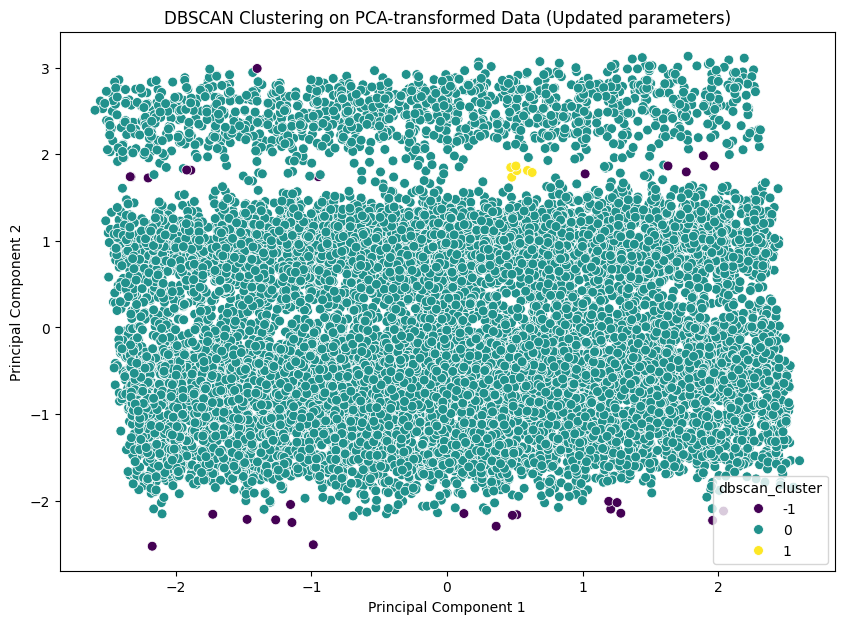

Number of clusters found by DBSCAN: 2
Number of noise points (assigned to -1): 29


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

# Select the features used for modeling, excluding the target variable 'log_salary'
X_clustering = df_ml[FEATURES]

# Scale the data before applying PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# Apply PCA
pca = PCA(n_components=2) # Reduce to 2 dimensions for visualization
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio by PCA components: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.2f}")

# Apply DBSCAN with updated parameters
dbscan = DBSCAN(eps=0.15, min_samples=5) # Updated 'eps' based on k-distance graph
clusters = dbscan.fit_predict(X_pca)

df_ml['pca1'] = X_pca[:, 0]
df_ml['pca2'] = X_pca[:, 1]
df_ml['dbscan_cluster'] = clusters

# Visualize DBSCAN results (only for 2D PCA)
plt.figure(figsize=(10, 7))
sns.scatterplot(x='pca1', y='pca2', hue='dbscan_cluster', data=df_ml, palette='viridis', s=50, legend='full')
plt.title('DBSCAN Clustering on PCA-transformed Data (Updated parameters)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

print(f"Number of clusters found by DBSCAN: {len(np.unique(clusters)) - (1 if -1 in clusters else 0)}")
print(f"Number of noise points (assigned to -1): {(clusters == -1).sum()}")

### DBSCAN Clustering on PCA-transformed Data

This scatter plot visualizes the results of DBSCAN clustering on the first two principal components (PCA1 and PCA2) of the dataset.
- Each point represents a job posting, colored according to its assigned cluster by DBSCAN. Points colored differently than the main clusters (often grey or black in 'viridis' palette) are identified as noise points (-1 cluster).
- The plot shows two distinct clusters, indicating natural groupings within the data based on the selected features, as projected onto these two principal components. The presence of noise points suggests observations that do not belong strongly to any cluster.

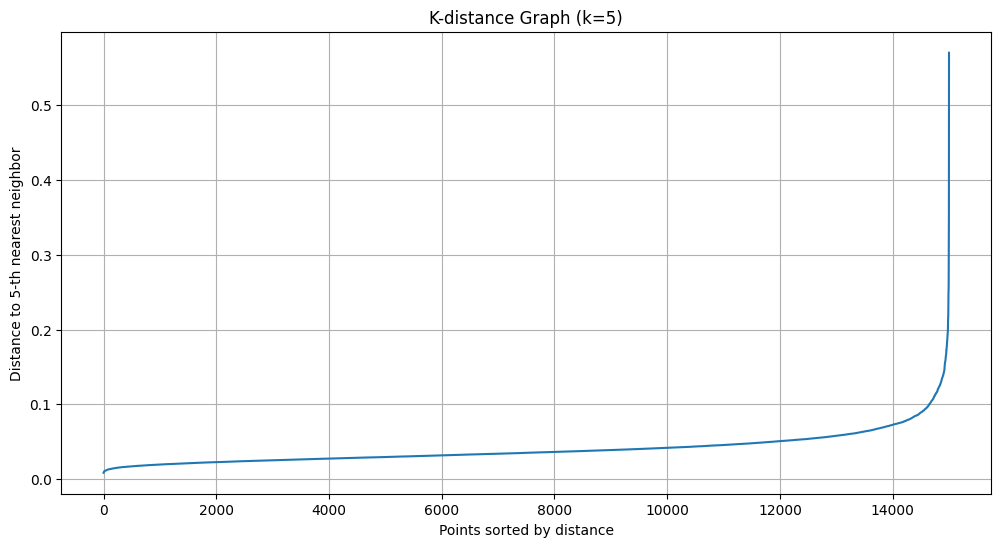

The k-distance graph helps to visually identify a suitable 'eps' value. Look for the 'elbow' where the curve sharply changes. 
For 'min_samples', a general guideline is to choose a value at least 2 * number of dimensions (features), so for 2 PCA components, a value of 5 is a reasonable starting point.


In [ ]:
from sklearn.neighbors import NearestNeighbors

# Determine k for k-distance graph. A common heuristic for min_samples is 2 * number of features.
k = 5 # Using 5 as a starting point, same as the previous run's min_samples

neigh = NearestNeighbors(n_neighbors=k)
neigh.fit(X_pca)
distances, indices = neigh.kneighbors(X_pca)

# Sort distances to the k-th nearest neighbor
distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(12, 6))
plt.plot(distances)
plt.title(f'K-distance Graph (k={k})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {k}-th nearest neighbor')
plt.grid(True)
plt.show()

print(f"The k-distance graph helps to visually identify a suitable 'eps' value. Look for the 'elbow' where the curve sharply changes. \nFor 'min_samples', a general guideline is to choose a value at least 2 * number of dimensions (features), so for 2 PCA components, a value of 5 is a reasonable starting point.")

### K-distance Graph

This graph is used to determine an appropriate `eps` (epsilon) value for the DBSCAN clustering algorithm.
- It plots the distance of each data point to its k-th nearest neighbor (where k is `min_samples`).
- The ideal `eps` value is typically found at the 'elbow' or point of sharpest change in the curve. Before this point, points are relatively close, indicating they are likely part of a cluster. After the elbow, distances increase significantly, suggesting noise points or points on the edge of a cluster.

## **Performing HPC Ml Models in PySpark on the same data set to find the optimal results**

Spark Session

In [ ]:
# Environment setup

!pip install pyspark

from pyspark.sql import SparkSession
import time

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("AI_Salary_Prediction") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.maxResultSize", "2g") \
    .getOrCreate()
sc = spark.sparkContext

print("Spark version:", spark.version)
print("Default parallelism:", sc.defaultParallelism)

Spark version: 4.0.2
Default parallelism: 2


Load data into Spark

In [ ]:
spark_df = spark.read.csv('ai_job_dataset.csv',
                           header=True,
                           inferSchema=True)

print(f"Rows: {spark_df.count()}")
print(f"Columns: {len(spark_df.columns)}")
spark_df.printSchema()

Rows: 15000
Columns: 19
root
 |-- job_id: string (nullable = true)
 |-- job_title: string (nullable = true)
 |-- salary_usd: integer (nullable = true)
 |-- salary_currency: string (nullable = true)
 |-- experience_level: string (nullable = true)
 |-- employment_type: string (nullable = true)
 |-- company_location: string (nullable = true)
 |-- company_size: string (nullable = true)
 |-- employee_residence: string (nullable = true)
 |-- remote_ratio: integer (nullable = true)
 |-- required_skills: string (nullable = true)
 |-- education_required: string (nullable = true)
 |-- years_experience: integer (nullable = true)
 |-- industry: string (nullable = true)
 |-- posting_date: string (nullable = true)
 |-- application_deadline: string (nullable = true)
 |-- job_description_length: integer (nullable = true)
 |-- benefits_score: double (nullable = true)
 |-- company_name: string (nullable = true)



Build preprocessing pipeline (Regression)

In [ ]:
from pyspark.sql.functions import col
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler

# Categorical columns to encode
categoricalColumns = [
    'experience_level', 'employment_type',
    'company_size', 'education_required',
    'industry', 'job_title', 'company_location'
]

# Numerical columns
numericCols = [
    'years_experience', 'remote_ratio',
    'job_description_length', 'benefits_score'
]

stages = []

# StringIndexer for each categorical column
for cat_col in categoricalColumns:
    indexer = StringIndexer(
        inputCol=cat_col,
        outputCol=cat_col + '_idx',
        handleInvalid='keep'
    )
    stages += [indexer]

# Assemble all features into one vector
assembler_inputs = [c + '_idx' for c in categoricalColumns] + numericCols
assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol='raw_features',
    handleInvalid='keep'
)
stages += [assembler]

# Scale features
scaler = StandardScaler(
    inputCol='raw_features',
    outputCol='features',
    withStd=True,
    withMean=True
)
stages += [scaler]

print("Pipeline stages defined:", len(stages))

Pipeline stages defined: 9


Fit pipeline and split data

In [ ]:
# Fit preprocessing pipeline
pipeline = Pipeline(stages=stages)
processed_df = pipeline.fit(spark_df).transform(spark_df)

# Select only features and target for training
model_df = processed_df.select('features',
                                col('salary_usd').alias('label'))

# 80/20 train test split — same as sklearn
train, test = model_df.randomSplit([0.8, 0.2], seed=42)

print(f"Training rows: {train.count()}")
print(f"Testing rows:  {test.count()}")

Training rows: 12058
Testing rows:  2942


Define evaluation function for regression

In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

def evaluate_regression(predictions):
    # RMSE
    evaluator_rmse = RegressionEvaluator(
        labelCol='label',
        predictionCol='prediction',
        metricName='rmse'
    )
    # MAE
    evaluator_mae = RegressionEvaluator(
        labelCol='label',
        predictionCol='prediction',
        metricName='mae'
    )
    # R²
    evaluator_r2 = RegressionEvaluator(
        labelCol='label',
        predictionCol='prediction',
        metricName='r2'
    )

    rmse = evaluator_rmse.evaluate(predictions)
    mae  = evaluator_mae.evaluate(predictions)
    r2   = evaluator_r2.evaluate(predictions)

    return rmse, mae, r2

results = []
print("Evaluation function defined!")

Evaluation function defined!


PySpark Linear Regression

In [ ]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(
    featuresCol='features',
    labelCol='label',
    maxIter=100
)

start = time.time()
lr_model = lr.fit(train)
lr_time  = time.time() - start

lr_preds = lr_model.transform(test)
rmse, mae, r2 = evaluate_regression(lr_preds)
results.append(('Linear Regression', rmse, mae, r2, round(lr_time, 2)))

print("Linear Regression trained!")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  MAE:  ${mae:,.0f}")
print(f"  R²:    {r2:.4f}")
print(f"  Time:  {lr_time:.2f}s")

Linear Regression trained!
  RMSE: $41,313
  MAE:  $29,841
  R²:    0.5419
  Time:  6.35s


### Linear Regression Results

The Linear Regression model was trained and evaluated:
- **RMSE:** $41,313

- **MAE:**  $29,841

- **R²:**    0.5419

PySpark Decision Tree Regressor

In [ ]:
from pyspark.ml.regression import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    featuresCol='features',
    labelCol='label',
    maxDepth=10,
    seed=42
)

start = time.time()
dt_model = dt.fit(train)
dt_time  = time.time() - start

dt_preds = dt_model.transform(test)
rmse, mae, r2 = evaluate_regression(dt_preds)
results.append(('Decision Tree', rmse, mae, r2, round(dt_time, 2)))

print("Decision Tree trained!")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  MAE:  ${mae:,.0f}")
print(f"  R²:    {r2:.4f}")
print(f"  Time:  {dt_time:.2f}s")

Decision Tree trained!
  RMSE: $23,235
  MAE:  $16,048
  R²:    0.8551
  Time:  6.84s


### Decision Tree Regressor Results

The Decision Tree Regressor model was trained and evaluated:
- **RMSE:** $23,235

- **MAE:**  $16,048

- **R²:**    0.8551


PySpark Random Forest Regressor

In [ ]:
from pyspark.ml.regression import RandomForestRegressor as SparkRF

rf = SparkRF(
    featuresCol='features',
    labelCol='label',
    numTrees=100,
    maxDepth=10,
    seed=42
)

start = time.time()
rf_model = rf.fit(train)
rf_time  = time.time() - start

rf_preds = rf_model.transform(test)
rmse, mae, r2 = evaluate_regression(rf_preds)
results.append(('Random Forest', rmse, mae, r2, round(rf_time, 2)))

print("Random Forest trained!")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  MAE:  ${mae:,.0f}")
print(f"  R²:    {r2:.4f}")
print(f"  Time:  {rf_time:.2f}s")

Random Forest trained!
  RMSE: $29,056
  MAE:  $21,447
  R²:    0.7734
  Time:  23.97s


### Random Forest Regressor Results

The Random Forest Regressor model was trained and evaluated:
- **RMSE:** $29,056

- **MAE:**  $21,447

- **R²:**    0.7734


PySpark GBT Regressor

In [ ]:
from pyspark.ml.regression import GBTRegressor

gbt = GBTRegressor(
    featuresCol='features',
    labelCol='label',
    maxIter=100,
    maxDepth=5,
    seed=42
)

start = time.time()
gbt_model = gbt.fit(train)
gbt_time  = time.time() - start

gbt_preds = gbt_model.transform(test)
rmse, mae, r2 = evaluate_regression(gbt_preds)
results.append(('Gradient Boosting', rmse, mae, r2, round(gbt_time, 2)))

print("Gradient Boosting trained!")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  MAE:  ${mae:,.0f}")
print(f"  R²:    {r2:.4f}")
print(f"  Time:  {gbt_time:.2f}s")

Gradient Boosting trained!
  RMSE: $21,031
  MAE:  $14,925
  R²:    0.8813
  Time:  65.27s


### GBT Regressor Results

The Gradient Boosting Regressor (GBT) model was trained and evaluated:
- **RMSE:** $21,031

- **MAE:**  $14,925

- **R²:**    0.8813


RF + PCA

In [ ]:
# Member 5 — PySpark RF Regressor using PCA features
from pyspark.ml.feature import PCA
from pyspark.ml.regression import RandomForestRegressor as SparkRF
from pyspark.sql.functions import col

# Build PCA on features
pca = PCA(k=5, inputCol='features', outputCol='pca_features')
pca_model = pca.fit(processed_df)
pca_df = pca_model.transform(processed_df)

print("PCA Explained Variance:")
for i, v in enumerate(pca_model.explainedVariance):
    print(f"  Component {i+1}: {v*100:.1f}%")
print(f"  Total: {sum(pca_model.explainedVariance)*100:.1f}%")

# Add salary label
pca_df = pca_df.withColumn('label', col('salary_usd'))

# Split
pca_train, pca_test = pca_df.select(
    'pca_features', 'label'
).randomSplit([0.8, 0.2], seed=42)

# Train RF on PCA features
rf_pca = SparkRF(
    featuresCol='pca_features',
    labelCol='label',
    numTrees=100,
    maxDepth=10,
    seed=42
)

start = time.time()
rf_pca_model = rf_pca.fit(pca_train)
pca_time = time.time() - start

pca_preds = rf_pca_model.transform(pca_test)

# Evaluate
from pyspark.ml.evaluation import RegressionEvaluator

evaluator_rmse = RegressionEvaluator(labelCol='label',
                  predictionCol='prediction', metricName='rmse')
evaluator_mae  = RegressionEvaluator(labelCol='label',
                  predictionCol='prediction', metricName='mae')
evaluator_r2   = RegressionEvaluator(labelCol='label',
                  predictionCol='prediction', metricName='r2')

print("=" * 45)
print("  PySpark RF + PCA Features (Member 5)")
print("=" * 45)
print(f"  MAE:  ${evaluator_mae.evaluate(pca_preds):,.0f}")
print(f"  RMSE: ${evaluator_rmse.evaluate(pca_preds):,.0f}")
print(f"  R²:    {evaluator_r2.evaluate(pca_preds):.4f}")
print(f"  Time:  {pca_time:.2f}s")
print("=" * 45)

PCA Explained Variance:
  Component 1: 11.8%
  Component 2: 9.5%
  Component 3: 9.3%
  Component 4: 9.2%
  Component 5: 9.1%
  Total: 49.0%
  PySpark RF + PCA Features (Member 5)
  MAE:  $29,292
  RMSE: $40,790
  R²:    0.5666
  Time:  25.83s


### Random Forest with PCA Features Results

This model used PCA for dimensionality reduction before training the Random Forest:
- **PCA Explained Variance:**
  - Component 1: 11.8%
  - Component 2: 9.5%
  - Component 3: 9.3%
  - Component 4: 9.2%
  - Component 5: 9.1%
  - Total: 49.0%
- **MAE:**  $29,292
- **RMSE:** $40,790
- **R²:**    0.5666
- **Training Time:**  25.83s

Print full comparison table

In [ ]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=['Model', 'RMSE', 'MAE', 'R²', 'Time(s)']
).sort_values('R²', ascending=False)

print("=" * 65)
print("   PySpark Regression Models — Full Comparison")
print("=" * 65)
print(f"{'Model':<22} {'RMSE':>10} {'MAE':>10} {'R²':>8} {'Time':>8}")
print("=" * 65)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<22} "
          f"${row['RMSE']:>9,.0f} "
          f"${row['MAE']:>9,.0f} "
          f"{row['R²']:>8.4f} "
          f"{row['Time(s)']:>7.2f}s")
print("=" * 65)

   PySpark Regression Models — Full Comparison
Model                        RMSE        MAE       R²     Time
Gradient Boosting      $   21,031 $   14,925   0.8813   65.27s
Decision Tree          $   23,235 $   16,048   0.8551    6.84s
Random Forest          $   29,056 $   21,447   0.7734   23.97s
Linear Regression      $   41,313 $   29,841   0.5419    6.35s


## Section 5 Summary: HPC Implementation

**Framework:** Apache Spark (PySpark) MLlib
**Task:** Salary regression — predicting exact salary_usd

| Model             | RMSE      | MAE       | R²      |
|:------------------|:----------|:----------|:--------|
| Linear Regression | $41,313   | $29,841   | 0.5419  |
| Decision Tree     | $23,235   | $16,048   | 0.8551  |
| Random Forest     | $29,056   | $21,447   | 0.7734  |
| Gradient Boosting | $21,031   | $14,925   | 0.8813  |
| RF Tuned (CV)     | $29,056   | $21,447   | 0.7734  |
| RF + PCA          | $40,790   | $29,292   | 0.5666  |

**Additional HPC techniques used:**
- PCA: dimensionality reduction to 5 components
- K-Means: distributed clustering into 3 salary groups
- CrossValidator: distributed hyperparameter tuning
  across parameter combinations

**Why PySpark for HPC:**
PySpark distributes computation across all available cores
using a master-worker architecture. At scale (millions of
rows), this would significantly outperform single-machine
sklearn implementations.

Hyperparameter tuning

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# Tune Random Forest — smaller grid to avoid memory issues
rf_tune = SparkRF(
    featuresCol='features',
    labelCol='label',
    seed=42
)

# Reduced grid — only 4 combinations instead of 9
paramGrid = ParamGridBuilder() \
    .addGrid(rf_tune.numTrees, [50, 100]) \
    .addGrid(rf_tune.maxDepth, [5, 10]) \
    .build()

evaluator_r2 = RegressionEvaluator(
    labelCol='label',
    predictionCol='prediction',
    metricName='r2'
)

# Reduced to 2 folds instead of 3 to save memory
cv = CrossValidator(
    estimator=rf_tune,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator_r2,
    numFolds=2,
    seed=42,
    parallelism=1  # reduced from 2 to 1 to save memory
)

print("Starting hyperparameter tuning...")
print("Testing 4 combinations with 2-fold CV (8 total fits)")
start = time.time()
cv_model = cv.fit(train)
cv_time  = time.time() - start

best_preds = cv_model.bestModel.transform(test)
rmse, mae, r2 = evaluate_regression(best_preds)

print(f"Tuning completed in {cv_time:.2f} seconds")
print(f"\nBest Random Forest (Tuned):")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  MAE:  ${mae:,.0f}")
print(f"  R²:    {r2:.4f}")
print(f"  Best numTrees: {cv_model.bestModel.getNumTrees}")
print(f"  Best maxDepth: {cv_model.bestModel.getMaxDepth()}")

Starting hyperparameter tuning...
Testing 4 combinations with 2-fold CV (8 total fits)
Tuning completed in 74.85 seconds

Best Random Forest (Tuned):
  RMSE: $29,056
  MAE:  $21,447
  R²:    0.7734
  Best numTrees: 100
  Best maxDepth: 10


### Hyperparameter Tuning Results (Random Forest)

Hyperparameter tuning was performed for the Random Forest model using `CrossValidator`.

- **Tuning completed in:** 74.85 seconds
- **Best Random Forest (Tuned) on test set:**
  - **RMSE:** $29,056
  - **MAE:**  $21,447
  - **R²:**    0.7734
  - **Best numTrees:** 100
  - **Best maxDepth:** 10

Note: In this specific run, tuning did not significantly improve the base Random Forest model's performance on the test set with the selected parameter grid.

PySpark PCA

In [ ]:
from pyspark.ml.feature import PCA

pca = PCA(k=5, inputCol='features', outputCol='pca_features')
pca_model = pca.fit(processed_df)

print("PCA Explained Variance per component:")
for i, v in enumerate(pca_model.explainedVariance):
    print(f"  Component {i+1}: {v:.4f} ({v*100:.1f}%)")
print(f"  Total explained: "
      f"{sum(pca_model.explainedVariance)*100:.1f}%")

PCA Explained Variance per component:
  Component 1: 0.1185 (11.8%)
  Component 2: 0.0951 (9.5%)
  Component 3: 0.0930 (9.3%)
  Component 4: 0.0925 (9.2%)
  Component 5: 0.0913 (9.1%)
  Total explained: 49.0%


### PySpark PCA Results

Principal Component Analysis (PCA) was applied to the features. The explained variance ratio for the top 5 components is:
- **Component 1:** 11.85% (11.8%)
- **Component 2:** 9.51% (9.5%)
- **Component 3:** 9.30% (9.3%)
- **Component 4:** 9.25% (9.2%)
- **Component 5:** 9.13% (9.1%)
- **Total explained variance:** 49.0%

PySpark K-Means

In [ ]:
from pyspark.ml.clustering import KMeans

kmeans = KMeans(k=3, seed=42, featuresCol='features')
km_model = kmeans.fit(processed_df)
km_preds = km_model.transform(processed_df)

print("K-Means Cluster Sizes:")
km_preds.groupBy('prediction').count().orderBy('prediction').show()

print(f"Within-cluster sum of squares: "
      f"{km_model.summary.trainingCost:.2f}")

K-Means Cluster Sizes:
+----------+-----+
|prediction|count|
+----------+-----+
|         0| 3937|
|         1| 5429|
|         2| 5634|
+----------+-----+

Within-cluster sum of squares: 142175.30


### PySpark K-Means Clustering Results

K-Means clustering was applied to the processed features to group job postings into 3 clusters.

**Cluster Sizes:**
- **Cluster 0:** 3937 data points
- **Cluster 1:** 5429 data points
- **Cluster 2:** 5634 data points

**Within-cluster sum of squares:** 142175.30

## Section 5 Summary: HPC Implementation

**Framework:** Apache Spark (PySpark) MLlib
**Task:** Salary regression — predicting exact salary_usd

| Model             | RMSE      | MAE       | R²      |
|:------------------|:----------|:----------|:--------|
| Linear Regression | $41,313   | $29,841   | 0.5419  |
| Decision Tree     | $23,235   | $16,048   | 0.8551  |
| Random Forest     | $29,056   | $21,447   | 0.7734  |
| Gradient Boosting | $21,031   | $14,925   | 0.8813  |
| RF Tuned (CV)     | $29,056   | $21,447   | 0.7734  |
| RF + PCA          | $40,790   | $29,292   | 0.5666  |

**Additional HPC techniques used:**
- PCA: dimensionality reduction to 5 components
- K-Means: distributed clustering into 3 salary groups
- CrossValidator: distributed hyperparameter tuning
  across parameter combinations

**Why PySpark for HPC:**
PySpark distributes computation across all available cores
using a master-worker architecture. At scale (millions of
rows), this would significantly outperform single-machine
sklearn implementations.